In [8]:
from copy import deepcopy
import os
import warnings

import numpy as np
import pandas as pd
import seaborn as sns

from mfsindy.cases.burgers import (
    BurgersConfig,
    build_burgers_intra_trajectory_artifacts,
    build_burgers_weak_validation_blocks,
    get_burgers_feature_names,
    run_burgers_experiment,
)
from mfsindy.experiments import (
    evaluate_weak_form_models,
    fit_intra_trajectory_gls_models,
    format_coefficient_equations,
    make_metric_scorer,
    optimize_hyperparams,
    split_spatiotemporal_trajectory,
)
from mfsindy.plots import bubble_hist

warnings.filterwarnings("ignore")
sns.set(context="paper", style="white", font_scale=1.1)

cfg = BurgersConfig(
    n_runs=25,
    K=500,
    noise_level=0.1,
    results_dir="results",
    results_filename="burgers_weighted_errors.csv",
)


# Burgers Part 2 — Intra-trajectory GLS

This notebook compares three different strategies for properly fit a SINDy model on a trajectory characterized by heteroskedastik noise: 
- *No weighting* (`WeakPDELibrary`)
- *Variance GLS* (`WeightedWeakPDELibrary`, weights = variance_scaled)
- *Unitary GLS* (`WeightedWeakPDELibrary`, weights = 1, only correlation effect)

## Governing equations

We consider the one-dimensional viscous Burgers equation on a periodic domain,
$$
u_t + u\,u_x = \nu u_{xx},
$$
where $u(x,t)$ denotes the scalar state variable and $\nu=0.1$ is the viscosity coefficient.


Let \(U=u\) denote the system state. To model perturbation error, we add a zero-mean random noise term \(\epsilon\) to the state, defining
$$
U^{\mathrm{noisy}} = U + \epsilon.
$$

The perturbation is assumed to satisfy
$$
\mathbb{E}[\epsilon] = 0.
$$

In the heteroscedastic setting used here, the pointwise noise variance depends on the magnitude of the spatial gradient. Specifically,
$$
\operatorname{Var}(\epsilon) = \left(\alpha |u_x|\right)^2,
$$
where $\alpha>0$ controls the noise amplitude. In our experiments, we take
$$
\alpha = 0.25.
$$

Thus, regions with larger spatial gradients are corrupted by stronger noise.

## Trajectories

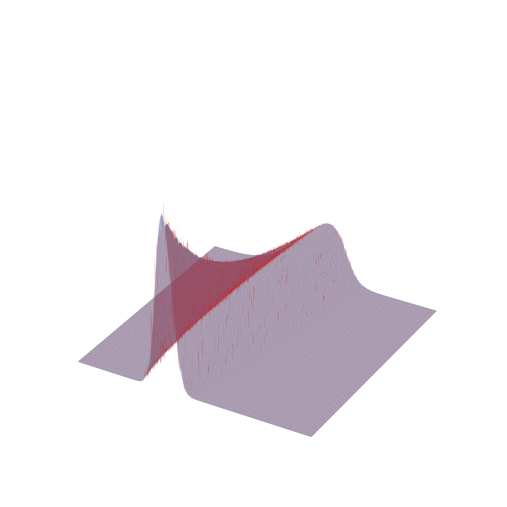

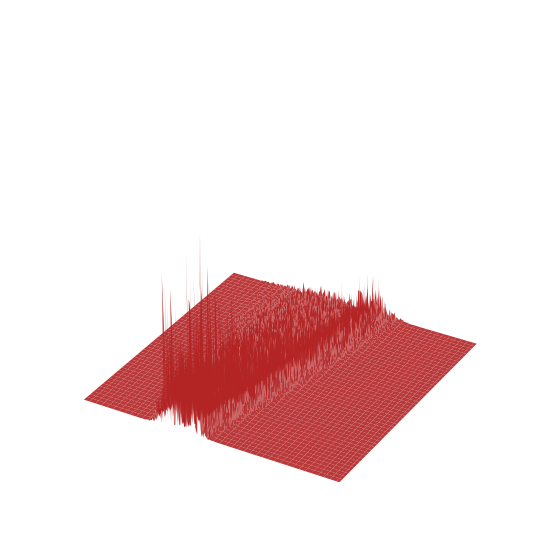

In [9]:
from mfsindy.cases.burgers import generate_burgers_dataset
from mfsindy.cases.burgers_plots import plot_trajectories_additive_noise, plot_residuals

X_true, t_grid, x_grid, _ = generate_burgers_dataset(
    n_traj=1,
    T=cfg.t1 - cfg.t0,
    dt=cfg.dt,
    L=cfg.L,
    NX=cfg.NX,
    nu=cfg.nu,
    noise_level=0.0,
    seed=0,
)
snapshot_ids = [len(t_grid) // 4, 3 * len(t_grid) // 4]
X_noisy = plot_trajectories_additive_noise(
    x_true=X_true[0],
    x_grid=x_grid,
    alpha=cfg.noise_level,
    time_indices=snapshot_ids,
)
plot_residuals(X_true[0], X_noisy, x_grid=x_grid, time_indices=snapshot_ids)


## Hyperparameter Selection

Use one noisy Burgers trajectory realisation, split it 80-20 in time, tune the weak-form hyperparameters separately for each weighting strategy by maximizing held-out weak-form $R^2$, then refit each model on the full trajectory and print the resulting equations.


In [10]:

# H_X_CANDIDATES = [cfg.L/50., cfg.L/20., cfg.L/10.]
# H_T_CANDIDATES = [cfg.t1/50., cfg.t1/20., cfg.t1/10.]

# SEARCH_GRID = {
#     "stlsq_threshold": [0.01, 0.05, 0.1],
#     "H_xt": [[h_x, h_t] for h_x in H_X_CANDIDATES for h_t in H_T_CANDIDATES],
# }

# X_clean_search_list, t_search, x_grid, _ = generate_burgers_dataset(
#     n_traj=1,
#     T=cfg.t1 - cfg.t0,
#     dt=cfg.dt,
#     L=cfg.L,
#     NX=cfg.NX,
#     nu=cfg.nu,
#     noise_level=0.0,
#     seed=cfg.seed_base,
# )
# X_clean_search = np.asarray(X_clean_search_list[0], dtype=float)
# if X_clean_search.shape[0] != t_search.shape[0]:
#     X_clean_search = np.swapaxes(X_clean_search, 0, 1)

# dx = x_grid[1] - x_grid[0]
# Ux = (np.roll(X_clean_search[..., 0], -1, axis=1) - np.roll(X_clean_search[..., 0], 1, axis=1)) / (2.0 * dx)
# variance_search = np.maximum((cfg.noise_level * np.abs(Ux)) ** 2, 1e-8)
# rng_search = np.random.default_rng(cfg.seed_base + 123)
# X_noisy_search = X_clean_search + np.sqrt(variance_search)[..., None] * rng_search.standard_normal(size=X_clean_search.shape)

# X_train, X_val, t_train, t_val = split_spatiotemporal_trajectory(
#     X_noisy_search,
#     t_search,
#     time_axis=0,
#     validation_fraction=0.2,
#     overlap=0,
# )
# variance_train, _, _, _ = split_spatiotemporal_trajectory(
#     variance_search,
#     t_search,
#     time_axis=0,
#     validation_fraction=0.2,
#     overlap=0,
# )

# methods = ["No weighting", "Variance GLS", "Ones GLS"]
# search_results = {}
# best_params_by_model = {}
# tuned_cfg_by_model = {}
# tuned_equations = {}

# def evaluate_candidate(candidate_cfg):
#     artifacts = build_burgers_intra_trajectory_artifacts(
#         X_train,
#         t_train,
#         x_grid,
#         variance=variance_train,
#         cfg=candidate_cfg,
#         weak_seed=candidate_cfg.seed_base + 40_000,
#     )
#     coef_map = fit_intra_trajectory_gls_models(candidate_cfg, artifacts, methods)
#     validation_blocks = build_burgers_weak_validation_blocks(
#         candidate_cfg,
#         [X_val],
#         t_grid=t_val,
#         x_grid=x_grid,
#         weak_seed=candidate_cfg.seed_base + 40_010,
#         group_name="validation",
#     )
#     return evaluate_weak_form_models(coef_map, validation_blocks)

# for target_model in methods:
#     search = optimize_hyperparams(
#         cfg,
#         param_grid=SEARCH_GRID,
#         evaluate=evaluate_candidate,
#         score_fn=make_metric_scorer(source=target_model, metric="weak_r2", source_col="model"),
#         maximize=True,
#     )
#     tuned_cfg = deepcopy(search.best_config)
#     search_results[target_model] = search
#     best_params_by_model[target_model] = search.best_params
#     tuned_cfg_by_model[target_model] = tuned_cfg
#     full_artifacts = build_burgers_intra_trajectory_artifacts(
#         X_noisy_search,
#         t_search,
#         x_grid,
#         variance=variance_search,
#         cfg=tuned_cfg,
#         weak_seed=tuned_cfg.seed_base + 40_001,
#     )
#     full_coef_map = fit_intra_trajectory_gls_models(tuned_cfg, full_artifacts, methods)
#     tuned_equations[target_model] = full_coef_map[target_model]

# feature_names = get_burgers_feature_names(
#     cfg,
#     t_grid=t_search,
#     x_grid=x_grid,
#     reference_trajectory=X_noisy_search,
# )
# print(pd.DataFrame(best_params_by_model).T)
# print(
#     format_coefficient_equations(
#         tuned_equations,
#         feature_names=feature_names,
#         state_names=("u_t",),
#         precision=3,
#     )
# )


## Run

In [11]:
# methods = ["No weighting", "Variance GLS", "Ones GLS"]
# df_errors_parts = []
# for method_name in methods:
#     method_cfg = deepcopy(tuned_cfg_by_model[method_name])
#     method_cfg.results_filename = f"burgers_part2_{method_name.lower().replace(' ', '_')}.csv"
#     df_method, _, _ = run_burgers_experiment(method_cfg)
#     df_errors_parts.append(df_method[df_method["method"] == method_name].copy())

# df_errors = pd.concat(df_errors_parts, ignore_index=True)
# errors_path = os.path.join(cfg.results_dir, cfg.results_filename)
# df_errors.to_csv(errors_path, index=False)


## Errors

In [12]:
methods = ["No weighting", "Variance GLS", "Ones GLS"]


errors_path = os.path.join(cfg.results_dir, cfg.results_filename)
df_errors = pd.read_csv(errors_path)

L1_errors = {
    m: df_errors[
        (df_errors["method"] == m) & (df_errors["metric"] == "L1")
    ]["value"].to_numpy()
    for m in methods
}
L0_errors = {
    m: df_errors[
        (df_errors["method"] == m) & (df_errors["metric"] == "L0")
    ]["value"].to_numpy()
    for m in methods
}

print("\nMedian L1 errors:")
for m in methods:
    print(m, np.median(L1_errors[m]))

print("\nMedian L0 support errors:")
for m in methods:
    print(m, np.median(L0_errors[m]))



Median L1 errors:
No weighting 0.0027848057668888
Variance GLS 0.0007156258313596
Ones GLS 0.0009544320610752

Median L0 support errors:
No weighting 1.5
Variance GLS 0.0
Ones GLS 0.0


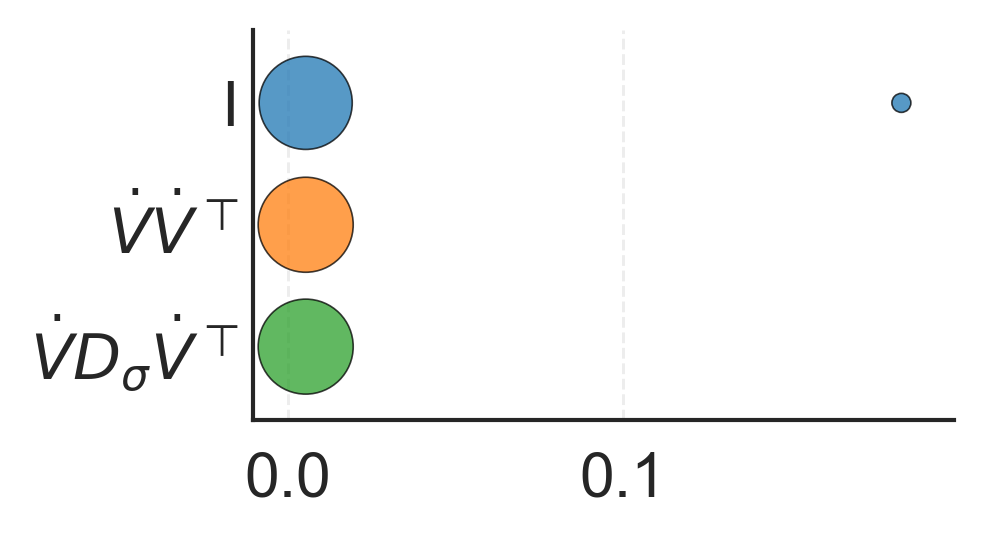

In [13]:
method_colors = {
    "No weighting": "tab:blue",
    "Variance GLS": "tab:green",
    "Ones GLS": "tab:orange",
}
methods = ["Variance GLS", "Ones GLS", "No weighting"]
labels = [r"$\dot{V}D_\sigma\dot{V}^\top$",r"$\dot{V}\dot{V}^\top$","I"]

all_l1_values = np.concatenate([
    np.asarray(L1_errors[m], dtype=float)
    for m in methods
])

xmin = float(np.min(all_l1_values))-0.001
xmax = float(np.max(all_l1_values))+0.001
pad = 0.05 * (xmax - xmin if xmax > xmin else 1.0)

l1_xlim = (xmin - pad, xmax + pad)

bubble_hist(
    errors_dict=L1_errors,
    n_bins=20,
    models_order=methods,
    colors=method_colors,
    labels=labels,
    xlim=l1_xlim,
    save_path="results/l1_2",
)


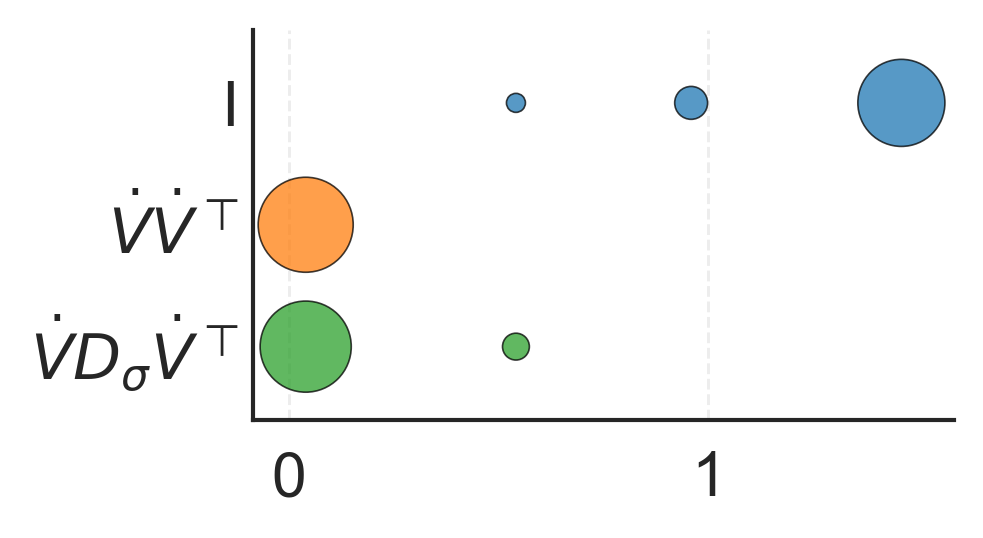

In [14]:
all_l0_values = np.concatenate([
    np.asarray(L0_errors[m], dtype=float)
    for m in methods
])

xmin = float(np.min(all_l0_values))-0.01
xmax = float(np.max(all_l0_values))+0.01

pad = 0.05 * (xmax - xmin if xmax > xmin else 1.0)
l0_xlim = (xmin - pad, xmax + pad)

bubble_hist(
    errors_dict=L0_errors,
    n_bins=20,
    models_order=methods,
    colors=method_colors,
    labels=labels,
    xlim=l0_xlim,
    save_path="results/l0_2"
)
